# 预处理

In [7]:
import os
from tensorflow.keras.datasets import imdb

#数据默认下载路径在 C:\Users\41507\.keras\datasets

# 加载前1万个词构成的数据集，index_from=3, 数据下载到data文件夹,词典默认大小是88582
num_words = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words, index_from=3)
print(type(x_train))
print(x_train.shape)
print(x_test.shape)
# 查看第一个样本
print("第一个训练样本：", x_train[0])
print("标签：", y_train[0:10])

# 加载imdb词典
word_index = imdb.get_word_index()
# imdb的字典是单词到索引的映射，索引要加3，0/1/2分别是padding, start, 未知符号
word_index = {word: idx + 3 for word, idx in word_index.items()}  # 0,1,2,3空出来做别的事,这里的idx是从1开始的,所以加3
word_index.update({
    "[PAD]": 0,  # 填充 token
    "[BOS]": 1,  # begin of sentence
    "[UNK]": 2,  # 未知 token
    "[EOS]": 3,  # end of sentence
})

print(x_train[1])


d:\Programs\Python\Python312\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


<class 'numpy.ndarray'>
(25000,)
(25000,)
第一个训练样本： [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
标签： [1 0 

In [8]:
word_index['fuck']

54485

In [9]:
# 构建索引到词的词典
index_to_word = {idx: word for word, idx in word_index.items()}

# 编写decode_review函数
def decode_review(encoded_review):
    return ' '.join([index_to_word.get(idx, '?') for idx in encoded_review])

# 测试decode_review函数，查看第一个训练样本原始文本内容
print("解码后的第一个训练样本：")
print(decode_review(x_train[0]))


解码后的第一个训练样本：
[BOS] this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert [UNK] is an amazing actor and now the same being director [UNK] father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for [UNK] and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also [UNK] to the two little boy's that played the [UNK] of norman and paul they were just brilliant children are often left out of the [UNK] list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be prai

In [10]:
import numpy as np

#如何将ndarray存入磁盘及读取
# 将训练和测试数据保存到磁盘
# np.save('x_train.npy', x_train, allow_pickle=True)
# np.save('y_train.npy', y_train, allow_pickle=True)
# np.save('x_test.npy', x_test, allow_pickle=True)
# np.save('y_test.npy', y_test, allow_pickle=True)

# # 从磁盘读取保存的数据
# x_train_loaded = np.load('x_train.npy', allow_pickle=True)
# y_train_loaded = np.load('y_train.npy', allow_pickle=True)
# x_test_loaded = np.load('x_test.npy', allow_pickle=True)
# y_test_loaded = np.load('y_test.npy', allow_pickle=True)

# print('x_train_loaded shape:', x_train_loaded.shape)
# print('y_train_loaded shape:', y_train_loaded.shape)
# print('x_test_loaded shape:', x_test_loaded.shape)
# print('y_test_loaded shape:', y_test_loaded.shape)


In [11]:
# 将测试集划分为验证集和测试集
# 从原始测试集中取前10000个样本作为验证集
x_val = x_test[:10000]
y_val = y_test[:10000]

# 剩余的15000个样本作为测试集
x_test = x_test[10000:]
y_test = y_test[10000:]

print(f"验证集样本数: {len(x_val)}")
print(f"测试集样本数: {len(x_test)}")
print(f"验证集标签示例: {y_val[:10]}")
print(f"测试集标签示例: {y_test[:10]}")

验证集样本数: 10000
测试集样本数: 15000
验证集标签示例: [0 1 1 0 1 1 1 0 0 1]
测试集标签示例: [1 1 0 1 0 0 1 0 1 1]


## 通过直方图来观察样本长度分布

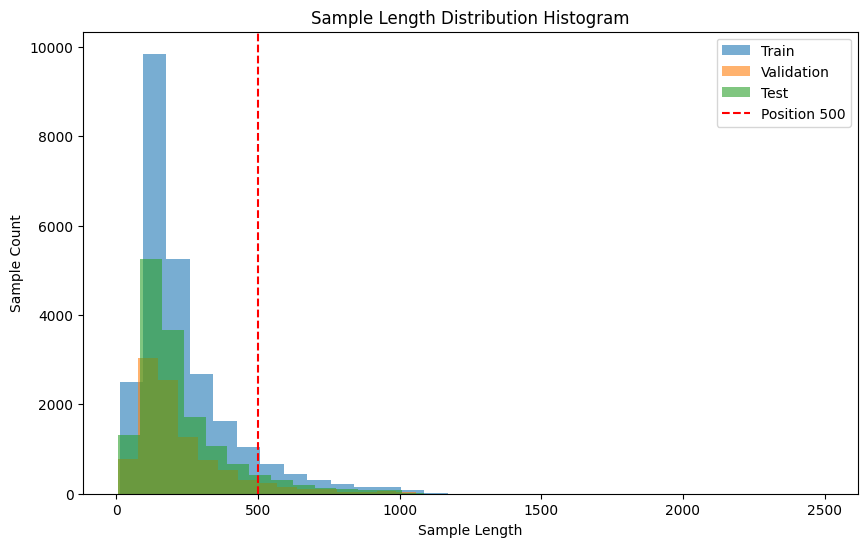

In [12]:
import matplotlib.pyplot as plt

# Calculate sample lengths
train_lengths = [len(seq) for seq in x_train]
val_lengths = [len(seq) for seq in x_val]
test_lengths = [len(seq) for seq in x_test]

plt.figure(figsize=(10, 6))
plt.hist(train_lengths, bins=30, alpha=0.6, label='Train')
plt.hist(val_lengths, bins=30, alpha=0.6, label='Validation')
plt.hist(test_lengths, bins=30, alpha=0.6, label='Test')
plt.axvline(x=500, color='r', linestyle='--', label='Position 500')
plt.xlabel('Sample Length')
plt.ylabel('Sample Count')
plt.title('Sample Length Distribution Histogram')
plt.legend()
plt.show()


# Tokenizer

In [13]:
from unittest import result


class Tokenizer:
    def __init__(self, word_index, index_to_word):
        """
        word_index: dict, 词 --> id，对应于词典
        index_to_word: dict, id --> 词，对应于词典
        """
        self.word_index = word_index
        self.index_to_word = index_to_word
        self.vocab_size = len(word_index)

        # Special tokens
        # 参照@01_embedding_padding_pooling.ipynb (21-24):
        # "[PAD]": 0,  # 填充 token
        # "[BOS]": 1,  # begin of sentence
        # "[UNK]": 2,  # 未知 token
        # "[EOS]": 3,  # end of sentence
        self.pad_token = "[PAD]"
        self.bos_token = "[BOS]"
        self.unk_token = "[UNK]"
        self.eos_token = "[EOS]"
        self.pad_id = self.word_index[self.pad_token]
        self.bos_id = self.word_index[self.bos_token]
        self.unk_id = self.word_index[self.unk_token]
        self.eos_id = self.word_index[self.eos_token]

    def encode(self, text, maxlen=None, padding='post', truncating='post',
               add_bos=False, add_eos=False):
        """
        参数:
            text: 列表，其中每个元素为长字符串（批量编码）
            maxlen: int 或 None，指定最大长度
            padding: 'pre' 或 'post'
            truncating: 'pre' 或 'post'
            add_bos: 是否加开始符（[BOS]）
            add_eos: 是否加结束符（[EOS]）
        返回: List[List[int]] ，每个样本的id序列
        """
        if not isinstance(text, list):
            raise ValueError("输入text应为字符串列表")

        # 计算需要的序列长度
        batch_max_len = max([len(seq) for seq in text]) #batch内最长序列长度
        if add_bos:
            batch_max_len += 1
        if add_eos:
            batch_max_len += 1

        # 如果maxlen为None或者batch内最大长度小于maxlen，使用batch内最大长度
        if maxlen is None or batch_max_len < maxlen:
            maxlen = batch_max_len

        result=[]
        for text in text:
            sequence = []

            # 添加开始标记
            if add_bos:
                sequence.append(self.bos_id)

            # 将词转换为索引
            for word in text:
                sequence.append(self.word_index.get(word, self.unk_id))

            # 添加结束标记
            if add_eos:
                sequence.append(self.eos_id)

            # 截断序列
            if len(sequence) > maxlen:
                if truncating == 'pre':
                    sequence = sequence[-maxlen:]
                else:  # truncating == 'post'
                    sequence = sequence[:maxlen]
            else:
                # 填充序列
                pad_length = maxlen - len(sequence)
                if pad_length > 0:
                    if padding == 'pre':
                        sequence = [self.pad_id] * pad_length + sequence
                    else:  # padding == 'post'
                        sequence = sequence + [self.pad_id] * pad_length

            result.append(sequence)

        return np.array(result)

    def decode(self, ids, remove_special=True):
        """
        参数:
            ids: 二维int列表
            remove_special: 是否移除特殊符号
        返回: 列表，每个元素是一条字符串（tokens拼接）
        """
        results = []
        special_tokens = {self.pad_token, self.bos_token, self.eos_token}  # 特殊符号集合
        for seq in ids:  # 遍历每个序列
            tokens = []
            for idx in seq:
                token = self.index_to_word.get(idx, self.unk_token)
                if remove_special and token in special_tokens: #默认移除pad，bos，eos
                    continue
                tokens.append(token)
            results.append(' '.join(tokens))

        return results


In [14]:
raw_text = ["hello world".split(), "tokenize text datas with batch".split(), "this is a test".split()]
raw_text

[['hello', 'world'],
 ['tokenize', 'text', 'datas', 'with', 'batch'],
 ['this', 'is', 'a', 'test']]

In [15]:
index_to_word[4825]

'hello'

In [16]:
tokenizer=Tokenizer(word_index,index_to_word)
encoded_text = tokenizer.encode(raw_text)
print(encoded_text)
decoded_text = tokenizer.decode(encoded_text)
print(decoded_text)


[[ 4825   182     0     0     0]
 [    2  3004     2    19 19233]
 [   14     9     6  2181     0]]
['hello world', '[UNK] text [UNK] with batch', 'this is a test']


# Dataset和DataLoader

In [17]:
a,b=zip(('a',1),('b',1),('c',0))
print(a)
print(b)


('a', 'b', 'c')
(1, 1, 0)


In [18]:
from torch.utils.data import Dataset, DataLoader
import torch
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        """
        参数:
            texts: 原始文本数据，列表形式，每个元素是一个句子的token列表
            labels: 标签数据，列表形式
        """
        self.texts = tokenizer.decode(texts)
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

def collate_fn(batch,max_len=500):
    """
    DataLoader的collate_fn，对批次数据进行编码和填充
    参数:
        batch: 一个批次的原始文本数据和标签
    返回:
        编码后的tensor和标签tensor
    """
    texts, labels = zip(*batch)
    # 先将每个文本字符串split成token列表
    token_lists = [text.split() for text in texts]
    # 使用tokenizer对批次数据进行编码
    encoded_batch = tokenizer.encode(token_lists,maxlen=max_len,padding='pre', add_bos=False, add_eos=True)
    return torch.tensor(encoded_batch, dtype=torch.long), torch.tensor(labels, dtype=torch.long)

# 创建训练集DataLoader
train_dataset = TextDataset(x_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)

# 创建验证集DataLoader
val_dataset = TextDataset(x_val, y_val)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

# 创建测试集DataLoader
test_dataset = TextDataset(x_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

# 测试训练集DataLoader
print("Training DataLoader:")
for batch_texts, batch_labels in train_dataloader:
    print("Batch texts shape:", batch_texts.shape)
    print("Batch labels shape:", batch_labels.shape)
    print("Batch content:")
    print(batch_texts)
    print("Batch labels:")
    print(batch_labels)
    print("Decoded batch:")
    decoded_batch = tokenizer.decode(batch_texts.tolist())
    print(decoded_batch)
    break  # 只显示第一个batch

print("-" * 50)
print("Validation DataLoader:")
for batch_texts, batch_labels in val_dataloader:
    print("Batch texts shape:", batch_texts.shape)
    print("Batch labels shape:", batch_labels.shape)
    break  # 只显示第一个batch

print("-" * 50)
print("Test DataLoader:")
for batch_texts, batch_labels in test_dataloader:
    print("Batch texts shape:", batch_texts.shape)
    print("Batch labels shape:", batch_labels.shape)
    break  # 只显示第一个batch


Training DataLoader:
Batch texts shape: torch.Size([64, 500])
Batch labels shape: torch.Size([64])
Batch content:
tensor([[   0,    0,    0,  ...,   19,   25,    3],
        [   0,    0,    0,  ...,   10,  590,    3],
        [   0,    0,    0,  ...,    6,  492,    3],
        ...,
        [   0,    0,    0,  ...,    4, 5136,    3],
        [   0,    0,    0,  ...,   23,  288,    3],
        [   0,    0,    0,  ...,    4, 5169,    3]])
Batch labels:
tensor([0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0,
        0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
        0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0])
Decoded batch:
["jean claude van damme tries to rescue his career by making the sequel of universal soldier but did that movie saved him i think he goes to hell after he dies br br in the first minute we see the inside of a facility where you can see the bad guy of the film scary huh but not as scary as the acting details are f

# 搭建分类模型

In [ ]:
import torch
import torch.nn as nn

class TextClassificationModel(nn.Module):
    def __init__(
        self, vocab_size, embedding_dim, hidden_dim, num_classes,
        rnn_layers=1, bidirectional=False
    ):
        """
        文本分类RNN模型
        Args:
            vocab_size (int): 词表大小，每个词都会分配一个唯一编号
            embedding_dim (int): 词向量的维度，Embedding输出向量维度
            hidden_dim (int): RNN隐状态(hidden state)向量维度
            num_classes (int): 分类任务的类别数（输出单元数）
            rnn_layers (int): RNN堆叠层数，默认为1
            bidirectional (bool): 是否使用双向RNN，默认为False
        """
        super().__init__()
        # nn.Embedding层: 输入(b, seq_len) -> 输出(b, seq_len, embedding_dim)
        # 用于将单词编号转换成稠密向量表示（嵌入）
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.bidirectional = bidirectional  # 记录是否双向，用于forward
        # RNN主体
        self.rnn = nn.RNN(
            input_size=embedding_dim,      # 每步输入的特征维度
            hidden_size=hidden_dim,        # 隐状态向量的维度
            num_layers=rnn_layers,         # 堆叠RNN层数
            batch_first=True,              # 输入输出张量第1维是batch
            nonlinearity='tanh',           # 激活函数，'tanh'或'relu'
            bidirectional=bidirectional    # 是否使用双向RNN
        )
        # 如果是双向，RNN输出维度需乘2；否则等于hidden_dim
        rnn_output_dim = hidden_dim * (2 if bidirectional else 1)
        # 分类头：先经过FC+ReLU，再FC映射到类别数
        self.fc1 = nn.Linear(rnn_output_dim, hidden_dim) # 第一层线性映射
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)    # 第二层线性映射到类别数

    def forward(self, x):
        '''
        前向过程
        Args:
            x (LongTensor): shape (batch_size, seq_len)，每个元素为单词的id
        Returns:
            logits (Tensor): shape (batch_size, num_classes)
        '''
        # 1. 嵌入层：将单词id映射到embedding向量
        embed = self.embedding(x)  # shape: (batch_size, seq_len, embedding_dim)
        # 2. 送入RNN, 获取所有时间步的输出(output)和最终隐状态h_n
        #    output: (batch, seq_len, hidden_dim*num_directions)
        #    h_n: (num_layers*num_directions, batch, hidden_dim)

        # 这里调用 self.rnn(embed) 实际上是把 embedding 层出来的结果送入 RNN 层进行序列建模
        # output 表示RNN对每个时间步（单词）产生的输出（用于某些任务比如序列标注），
        # h_n 是RNN“最后一步”的隐藏状态（可理解为对整句话的高维向量表示），
        # 后面我们用的其实主要是 h_n！

        # 注意 h_n 的第1维不是 batch，是 (num_layers * num_directions)
        # 这是因为RNN的每一层、每个方向都会输出一个最终的隐藏状态（每一层“最后一个时间步”的隐藏状态）。
        # 所以 h_n 的 shape 是 (num_layers * num_directions, batch, hidden_dim)
        # batch_first=True 只影响 input/output 张量的 batch 排在第1维，
        # 但 h_n 作为最终隐藏状态，它是以“层和方向”为第1维来组织的，其次是 batch，再是 hidden_dim。
        
        # INSERT_YOUR_CODE
        # ==========================
        # 在这里 input 是 nn.Embedding 层的输出（也就是 embed），
        #        embed 的 shape: (batch_size, seq_len, embedding_dim)
        # RNN 层的输出 output 表示每个时间步所有隐藏状态
        #        output 的 shape: (batch_size, seq_len, hidden_dim * num_directions)
        # h_n 表示每一层、每一方向最后的隐藏状态（汇总每个sequence的全局特征）
        #        h_n 的 shape: (num_layers * num_directions, batch_size, hidden_dim)
        # 通常我们做句子/文本级分类任务时，主要使用 h_n 里的最后一层隐藏状态，
        # 它代表整个序列的信息“压缩版”。
        output, h_n = self.rnn(embed)
        # 3. 取最后一层、每个方向的hidden拼起来作为句子的全局表示
        if self.bidirectional:
            # 双向RNN需要拼接正向和反向（最后一层）hidden
            # h_n 形状：(num_layers * 2, batch, hidden_dim)
            # 最后两行(-2:,:)分别对应最后一层正向和反向
            
            # 为什么要有这一步？
            # 对于双向RNN，h_n 的 shape 是 (num_layers*2, batch, hidden_dim)，
            # 每一层正向和反向的最后hidden state彼此独立存储在h_n中最后两行。
            # 我们取最后一层的正向和反向 hidden state（即 h_n[-2,:,:] 和 h_n[-1,:,:]），把它们拼在一起，
            # 可以让模型同时利用来自句子正序和逆序的信息进行分类。

            last_layer_h_n = h_n[-2:,:,:]   # (2, batch, hidden_dim)
            # 分别取正/反向最后的hidden，然后拼接
            # 这里 dim=-1 的意思是沿着最后一个维度（hidden_dim维）拼接，
            # 也就是把正向的hidden和反向的hidden拼成一个更长的向量（长度变成hidden_dim*2），
            # 这样输出的 last_hidden shape 就是 (batch, hidden_dim*2)
            last_hidden = torch.cat([
                last_layer_h_n[0],  # 正向
                last_layer_h_n[1]   # 反向
            ], dim=-1)  # dim=-1表示在最后一个维度拼接（特征拼接，不是batch拼接）
        else:
            # 单向RNN则直接取最后一层的hidden (batch, hidden_dim)
            # 这里的 h_n 是一个形状为 (num_layers * num_directions, batch, hidden_dim) 的张量。
            # 对于单向RNN（num_directions=1），只需要最后一层的hidden：
            # h_n[-1] 其实就是最后一层、最后一个时间步的隐藏状态，形状是 (batch, hidden_dim)

            # 对于单向RNN，num_directions=1，所以 h_n.shape 为 (num_layers, batch, hidden_dim)。
            # h_n[-1] 即取最后一层的隐藏状态（对应“最后一层”的所有batch样本），
            # 输出 shape: (batch, hidden_dim)，把第0维（RNN层数）去掉了，因为我们通常只关心最后一层的输出。
            # 这里不取 output 的最后一个时间步而取 h_n[-1]，是因为 h_n 就是每个RNN层/方向最后时间步的hidden状态。
            

            last_hidden = h_n[-1]
        # 4. 分类头：两层全连接（带ReLU激活），输出logits
        out = self.fc1(last_hidden)  # shape: (batch, hidden_dim)
        out = self.relu(out)
        out = self.fc2(out)  # shape: (batch, num_classes)
        return out

# =======================
# 参数举例及模型实例化
# =======================
# vocab_size: 词表大小; embedding_dim: 词向量维数
# hidden_dim: RNN隐层维度; num_classes: 分类类别数; rnn_layers: RNN层数; bidirectional: 是否为双向RNN
vocab_size = num_words         # 词表大小（应由数据/分词器决定）
embedding_dim = 16            # 词向量维度，可自定
hidden_dim = 64               # RNN单元的隐藏层维度
num_classes = 1               # 输出类别数（如二分类填1，多分类填类别数）
rnn_layers = 1                # RNN层数
bidirectional = False         # 是否采用双向RNN

# 构造模型实例
model = TextClassificationModel(
    vocab_size, embedding_dim, hidden_dim, num_classes,
    rnn_layers=rnn_layers, bidirectional=bidirectional
)


In [20]:
# 编写前向计算验证模型
# 假设有一个 batch 输入张量（随机生成，并假设最大长度为 10）
batch_size = 2
seq_len = 10
x = torch.randint(0, vocab_size, (batch_size, seq_len), dtype=torch.long)
print(x.shape)
with torch.no_grad():
    outputs = model(x)
    print("Output shape:", outputs.shape)
    print("Output:", outputs)


torch.Size([2, 10])
Output shape: torch.Size([2, 1])
Output: tensor([[ 0.0085],
        [-0.0560]])


In [ ]:
# 统计并详细解释模型参数量
total_params = 0
print("参数量统计与说明：")
for name, param in model.named_parameters():
    num = param.numel()
    shape = tuple(param.shape)
    # 打印每个参数的名字、形状和数量
    print(f"{name}: 形状={shape}, 参数个数={num}")
    total_params += num

print(f"\n模型总参数量: {total_params}")

# 额外解释说明：
# - 每一层参数的名称(name)通常以子模块名称作为前缀，以便区分不同的层和权重类型（如embedding层、RNN权重、全连接层等）。
# - param.shape显示该参数张量的形状。例如，(100,16) 表示100个词，每个词向量为16维。
# - param.numel() 统计该权重张量总共有多少个可训练参数（即所有元素的数量）。
# - 总参数量即为所有可训练权重和偏置项的数量之和。

参数量统计：
embedding.weight: 160000
rnn.weight_ih_l0: 1024
rnn.weight_hh_l0: 4096
rnn.bias_ih_l0: 64
rnn.bias_hh_l0: 64
fc1.weight: 4096
fc1.bias: 64
fc2.weight: 64
fc2.bias: 1
模型总参数量: 169473


In [16]:
64*64

4096

# 训练

In [17]:
len(train_dataloader)

391

In [21]:
from torch import device
from wangdao_train import Trainer

# 定义损失函数和优化器
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# 假定 train_loader, val_loader, device 已经准备好
trainer = Trainer(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100,  # 可调整
)

# 开始训练
trainer.train_binary(num_epochs=20)


[Step 100] Val Loss: 0.6908 Val Acc: 0.5341
[Step 200] Val Loss: 0.6820 Val Acc: 0.5625
[Step 300] Val Loss: 0.6749 Val Acc: 0.5745
Epoch [1/20] Train Loss: 0.6820 Acc: 0.5580 | Val Loss: 0.6749 Val Acc: 0.5745
[Step 400] Val Loss: 0.6578 Val Acc: 0.6103
[Step 500] Val Loss: 0.6299 Val Acc: 0.6497
[Step 600] Val Loss: 0.6937 Val Acc: 0.5214
[Step 700] Val Loss: 0.6929 Val Acc: 0.4972
Epoch [2/20] Train Loss: 0.6751 Acc: 0.5609 | Val Loss: 0.6929 Val Acc: 0.4972
[Step 800] Val Loss: 0.6940 Val Acc: 0.4966
[Step 900] Val Loss: 0.6932 Val Acc: 0.5053
[Step 1000] Val Loss: 0.6925 Val Acc: 0.5394
[Step 1100] Val Loss: 0.6916 Val Acc: 0.5379
Epoch [3/20] Train Loss: 0.6929 Acc: 0.5115 | Val Loss: 0.6916 Val Acc: 0.5379
[Step 1200] Val Loss: 0.6923 Val Acc: 0.5092
[Step 1300] Val Loss: 0.6909 Val Acc: 0.5316
[Step 1400] Val Loss: 0.6939 Val Acc: 0.5067
[Step 1500] Val Loss: 0.6919 Val Acc: 0.5124
Epoch [4/20] Train Loss: 0.6915 Acc: 0.5177 | Val Loss: 0.6919 Val Acc: 0.5124
[Step 1600] Val Lo

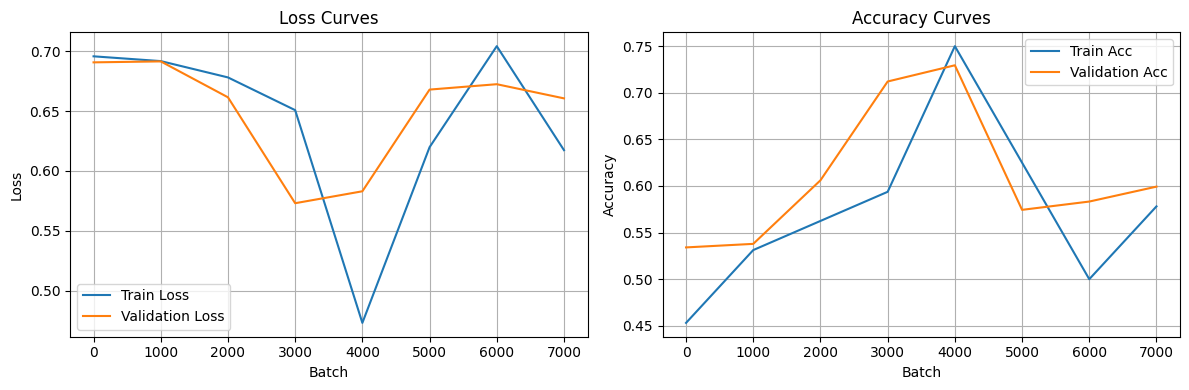

In [23]:
trainer.plot_curves()

In [24]:
vocab_size = num_words
embedding_dim = 16
hidden_dim = 64
num_classes = 1
rnn_layers = 1
bidirectional = True

model = TextClassificationModel(vocab_size, embedding_dim, hidden_dim, num_classes, rnn_layers=rnn_layers, bidirectional=bidirectional)

[Step 100] Val Loss: 0.6928 Val Acc: 0.5143
[Step 200] Val Loss: 0.6833 Val Acc: 0.5529
[Step 300] Val Loss: 0.6865 Val Acc: 0.5532
Epoch [1/20] Train Loss: 0.6875 Acc: 0.5373 | Val Loss: 0.6865 Val Acc: 0.5532
[Step 400] Val Loss: 0.6627 Val Acc: 0.6024
[Step 500] Val Loss: 0.6930 Val Acc: 0.5092
[Step 600] Val Loss: 0.6970 Val Acc: 0.5029
[Step 700] Val Loss: 0.6938 Val Acc: 0.4976
Epoch [2/20] Train Loss: 0.6882 Acc: 0.5208 | Val Loss: 0.6938 Val Acc: 0.4976
[Step 800] Val Loss: 0.6932 Val Acc: 0.5048
[Step 900] Val Loss: 0.6953 Val Acc: 0.4947
[Step 1000] Val Loss: 0.6935 Val Acc: 0.5071
[Step 1100] Val Loss: 0.6944 Val Acc: 0.4991
Epoch [3/20] Train Loss: 0.6938 Acc: 0.4986 | Val Loss: 0.6944 Val Acc: 0.4991
[Step 1200] Val Loss: 0.6930 Val Acc: 0.5037
[Step 1300] Val Loss: 0.6935 Val Acc: 0.5015
[Step 1400] Val Loss: 0.6938 Val Acc: 0.4994
[Step 1500] Val Loss: 0.6938 Val Acc: 0.5024
Epoch [4/20] Train Loss: 0.6935 Acc: 0.5041 | Val Loss: 0.6938 Val Acc: 0.5024
[Step 1600] Val Lo

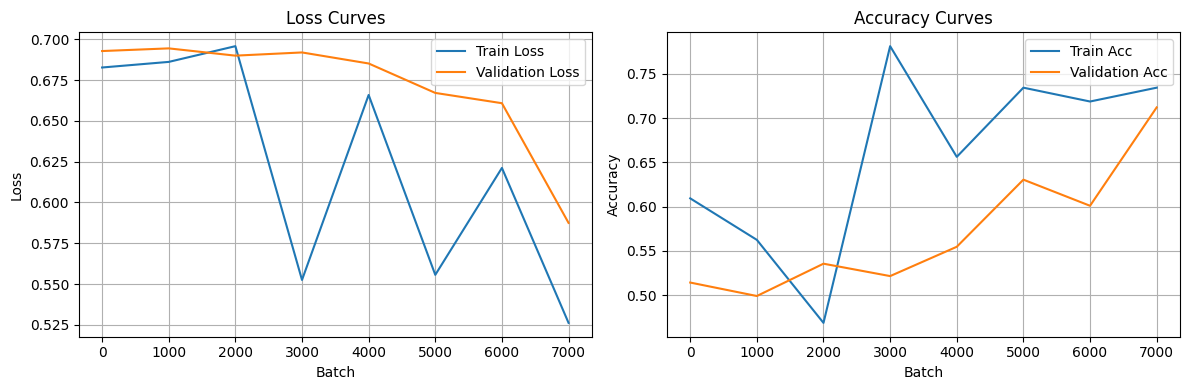

In [25]:
from torch import device
from wangdao_train import Trainer

# 定义损失函数和优化器
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# 假定 train_loader, val_loader, device 已经准备好
trainer = Trainer(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100,  # 可调整
    early_stopping_kwargs=dict(patience=5, min_delta=1e-4, mode='max'),
)

# 开始训练
trainer.train_binary(num_epochs=20)
trainer.plot_curves()

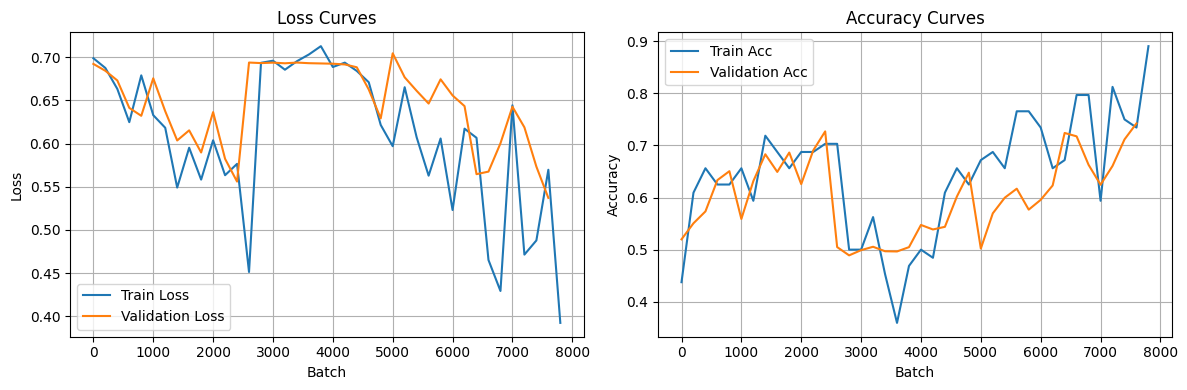

In [25]:
trainer.plot_curves(200)